# Which Matrices Have an Inverse?

*Course notes for **Math for Machine Learning**, C1 · W3 · L2 · V06 — "Which Matrices Have an Inverse" (DeepLearning.AI).*

The previous video showed that *some* matrices have an inverse and some don't. What's the **rule**? It's something you already know — and it mirrors how **numbers** work.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. Matrices behave like numbers

Some numbers have a **multiplicative inverse**, some don't:

- $5^{-1} = \tfrac15 = 0.2$, $\;\;8^{-1} = \tfrac18 = 0.125$ — every **non-zero** number has one.
- $0$ has **no** inverse: there is no number that times $0$ gives $1$.

Matrices are the same: **most** have an inverse, but some — like the singular matrix from the last video — do not.

## 2. The rule: non-singular $\Leftrightarrow$ invertible

The dividing line is **singularity**:

| | has an inverse? | name |
|---|---|---|
| **non-singular** matrix | **yes**, always | *invertible* |
| **singular** matrix | **never** | *non-invertible* |

So "non-singular", "invertible", and "has an inverse" all mean the same thing.

## 3. The determinant tells you instantly

The clean test is the **determinant**, echoing the number analogy exactly:

$$ \det(M) \neq 0 \;\Longleftrightarrow\; M \text{ is invertible}, \qquad \det(M) = 0 \;\Longleftrightarrow\; M \text{ is NOT invertible}. $$

A **non-zero determinant** behaves like a **non-zero number** (has an inverse); a **zero determinant** behaves like the number **$0$** (no inverse).

> **Remember it this way:** non-zero determinant → inverse exists; zero determinant → no inverse.

Let's check the three matrices from the lesson — the first two are invertible, the third is singular:

In [2]:
matrices = {
    'A = [[3,1],[1,2]]': np.array([[3, 1], [1, 2]]),
    'B = [[5,2],[1,2]]': np.array([[5, 2], [1, 2]]),
    'S = [[1,1],[2,2]]': np.array([[1, 1], [2, 2]]),   # singular
}

for name, Mx in matrices.items():
    det = np.linalg.det(Mx)
    invertible = not np.isclose(det, 0.0)
    print(f'{name:22s}  det = {det:6.2f}   ->  {"invertible" if invertible else "SINGULAR (no inverse)"}')

A = [[3,1],[1,2]]       det =   5.00   ->  invertible
B = [[5,2],[1,2]]       det =   8.00   ->  invertible
S = [[1,1],[2,2]]       det =   0.00   ->  SINGULAR (no inverse)


In [3]:
# A small helper: does an inverse exist? (guard np.linalg.inv with the determinant)
def has_inverse(Mx):
    return not np.isclose(np.linalg.det(Mx), 0.0)

for name, Mx in matrices.items():
    if has_inverse(Mx):
        print(f'{name}: inverse =\n{np.linalg.inv(Mx)}\n')
    else:
        print(f'{name}: no inverse (determinant is 0)\n')

A = [[3,1],[1,2]]: inverse =
[[ 0.4 -0.2]
 [-0.2  0.6]]

B = [[5,2],[1,2]]: inverse =
[[ 0.25  -0.25 ]
 [-0.125  0.625]]

S = [[1,1],[2,2]]: no inverse (determinant is 0)



## 4. Geometric intuition (why zero determinant $\Rightarrow$ no inverse)

The determinant is the **signed area** of the parallelogram the unit square maps to. A **singular** matrix squashes the square down to a **line** (zero area) — it collapses the 2D plane onto a lower dimension. Once everything is flattened onto a line, you **can't undo it** (many points map to the same place), so no inverse can exist. A non-zero determinant means the parallelogram still has area, so the map is reversible.

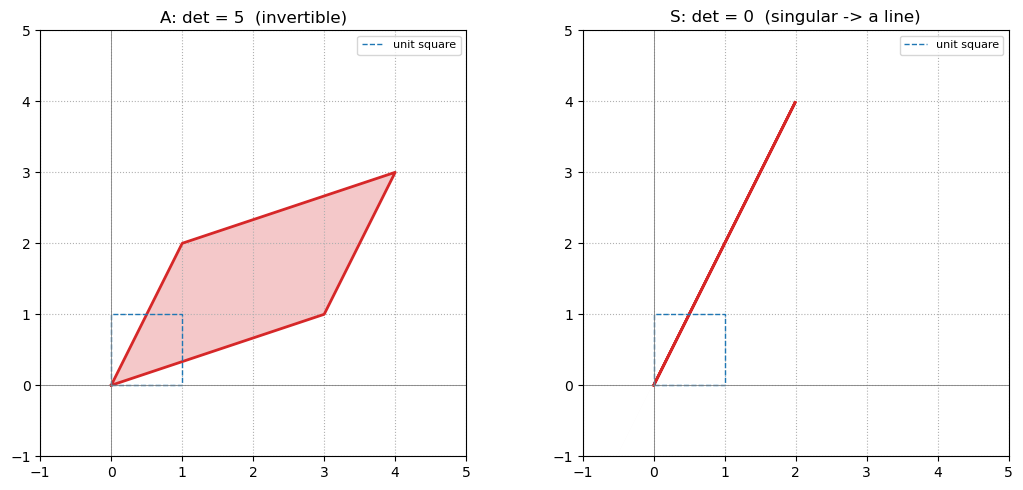

In [4]:
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
A = np.array([[3, 1], [1, 2]])   # det 5  -> area preserved-ish, invertible
S = np.array([[1, 1], [2, 2]])   # det 0  -> collapses to a line

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, Mx, ttl in [(axes[0], A, f'A: det = {np.linalg.det(A):.0f}  (invertible)'),
                    (axes[1], S, f'S: det = {np.linalg.det(S):.0f}  (singular -> a line)')]:
    img = Mx @ square
    ax.fill(img[0], img[1], color='C3', alpha=0.25)
    ax.plot(img[0], img[1], color='C3', lw=2)
    ax.plot(square[0], square[1], color='C0', ls='--', lw=1, label='unit square')
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.set_title(ttl); ax.legend(fontsize=8)
    ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
plt.tight_layout(); plt.show()

## Summary

- A matrix has an inverse **iff it is non-singular** (= *invertible*); singular matrices are *non-invertible* and never have one.
- The quick test is the **determinant**: $\det \neq 0 \Rightarrow$ invertible; $\det = 0 \Rightarrow$ no inverse — exactly like non-zero numbers vs. $0$.
- **Geometrically**, a zero determinant means the transformation **collapses area** (squashes the plane onto a line), which cannot be undone.
- In NumPy: `np.linalg.det(M)` for the test; guard `np.linalg.inv(M)` with it to avoid `LinAlgError` on singular matrices.